<a href="https://colab.research.google.com/github/njwbilll/Tugas-2_scikit-learn-Cookbook-O-Reilly-_Najwa-Bilqis-Al-Khalidah/blob/main/11_Novelty_and_Outlier_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 11: Novelty and Outlier Detection

**Referensi:** scikit-learn Cookbook, Third Edition - John Sukup (Packt Publishing, 2025)

---

## Ringkasan Chapter

Chapter 11 membahas teknik deteksi anomali dalam machine learning, mencakup dua konsep utama: **outlier detection** (mendeteksi data yang menyimpang dalam dataset yang tidak berlabel) dan **novelty detection** (mendeteksi data baru yang berbeda dari data pelatihan normal). Chapter ini memperkenalkan tiga algoritma utama dari scikit-learn: Isolation Forest, One-Class SVM, dan Local Outlier Factor (LOF), beserta strategi memilih teknik yang tepat sesuai karakteristik data.

### Topik yang Dibahas:
1. Pengantar deteksi outlier dan novelty
2. Isolation Forest untuk deteksi anomali
3. One-Class SVM untuk novelty detection
4. Local Outlier Factor (LOF) untuk deteksi outlier lokal
5. Evaluasi model deteksi outlier
6. Menangani outlier yang terdeteksi
7. Memilih teknik deteksi yang tepat

---

## Setup: Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(2024)
print("Library berhasil diimport.")

Library berhasil diimport.


---
## 1. Pengantar Deteksi Outlier dan Novelty

### Penjelasan Teori

Dalam machine learning tanpa pengawasan (unsupervised), sering kali kita perlu mengidentifikasi data yang "tidak normal" atau berbeda dari pola umum. Terdapat dua istilah penting yang perlu dibedakan:

**Outlier Detection (Deteksi Pencilan):**
- Digunakan ketika data pelatihan sudah mengandung anomali (data tidak bersih).
- Tujuannya adalah menemukan titik data yang menyimpang jauh dari mayoritas distribusi.
- Contoh: mendeteksi transaksi penipuan dalam dataset riwayat transaksi yang bercampur.

**Novelty Detection (Deteksi Kebaruan):**
- Digunakan ketika data pelatihan hanya berisi data "normal".
- Model mempelajari batas data normal, lalu mendeteksi data baru yang berada di luar batas tersebut.
- Contoh: melatih model pada sensor mesin yang berfungsi normal, lalu mendeteksi kerusakan dari sensor baru.

**Parameter `contamination`:**
Sebagian besar algoritma deteksi anomali menggunakan parameter ini untuk mengindikasikan proporsi perkiraan anomali dalam dataset. Nilai default umumnya adalah `'auto'` atau `0.1` (10%).

**Konvensi label dalam scikit-learn:**
- `+1` = inlier (normal)
- `-1` = outlier atau novelty (anomali)

In [2]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler

# Simulasi dataset dengan outlier sintetis
# Data normal: distribusi Gaussian
n_inliers = 300
n_outliers = 30

rng = np.random.RandomState(2024)
X_inliers = 0.3 * rng.randn(n_inliers, 2)
X_outliers = rng.uniform(low=-4, high=4, size=(n_outliers, 2))

X_all = np.vstack([X_inliers, X_outliers])
y_true = np.hstack([
    np.ones(n_inliers, dtype=int),
    -np.ones(n_outliers, dtype=int)
])

print(f"Total sampel:   {X_all.shape[0]}")
print(f"Inliers:        {n_inliers}")
print(f"Outliers:       {n_outliers}")
print(f"Tingkat kontaminasi nyata: {n_outliers / len(X_all):.2%}")

Total sampel:   330
Inliers:        300
Outliers:       30
Tingkat kontaminasi nyata: 9.09%


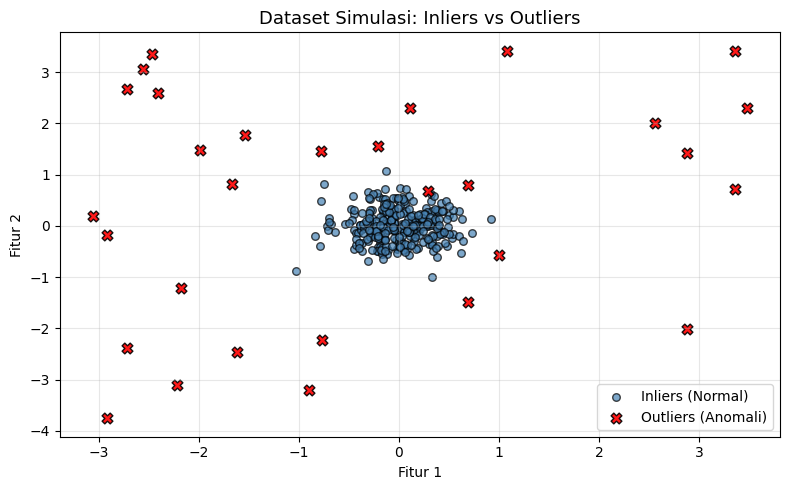

Pengamatan: Outlier (merah) tersebar jauh di luar klaster data normal (biru).


In [3]:
# Visualisasi dataset
plt.figure(figsize=(8, 5))
plt.scatter(X_inliers[:, 0], X_inliers[:, 1],
            color='steelblue', edgecolor='k', s=30, label='Inliers (Normal)', alpha=0.7)
plt.scatter(X_outliers[:, 0], X_outliers[:, 1],
            color='red', edgecolor='k', s=60, marker='X', label='Outliers (Anomali)', alpha=0.9)
plt.title('Dataset Simulasi: Inliers vs Outliers', fontsize=13)
plt.xlabel('Fitur 1')
plt.ylabel('Fitur 2')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Pengamatan: Outlier (merah) tersebar jauh di luar klaster data normal (biru).")

---
## 2. Isolation Forest

### Penjelasan Teori

**Isolation Forest** adalah algoritma deteksi anomali berbasis ensemble tree yang bekerja berdasarkan prinsip sederhana namun powerful: **anomali lebih mudah untuk diisolasi** dibandingkan data normal.

**Cara kerjanya:**
1. Algoritma secara acak memilih sebuah fitur, lalu membuat split acak antara nilai minimum dan maksimum fitur tersebut.
2. Proses ini diulang secara rekursif untuk membangun sebuah pohon isolasi (isolation tree).
3. Anomali, karena berada jauh dari klaster utama, akan membutuhkan lebih **sedikit split** untuk diisolasi (path yang lebih pendek di pohon).
4. Data normal membutuhkan lebih **banyak split** untuk diisolasi (path yang lebih panjang).
5. Skor anomali dihitung berdasarkan rata-rata panjang path di seluruh pohon dalam ensemble.

**Keunggulan Isolation Forest:**
- Sangat efisien untuk dataset besar dan berdimensi tinggi.
- Tidak memerlukan asumsi distribusi data.
- Mendukung prediksi pada data baru (predict pada data yang belum pernah dilihat).

**Kelemahan:**
- Kurang efektif ketika anomali membentuk klaster tersendiri.
- Sensitif terhadap pemilihan parameter `contamination`.

**Parameter penting:**
- `n_estimators`: Jumlah pohon dalam ensemble (default 100).
- `contamination`: Proporsi perkiraan outlier dalam data.
- `max_samples`: Jumlah sampel untuk melatih setiap pohon.

In [4]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

# Latih Isolation Forest
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.1,
    random_state=2024
)
iso_forest.fit(X_all)

# Prediksi: +1 = inlier, -1 = outlier
y_pred_iso = iso_forest.predict(X_all)
scores_iso  = iso_forest.decision_function(X_all)  # skor anomali

print("Isolation Forest - Hasil Prediksi:")
print(f"  Diprediksi sebagai inlier  (+1): {(y_pred_iso == 1).sum()}")
print(f"  Diprediksi sebagai outlier (-1): {(y_pred_iso == -1).sum()}")

Isolation Forest - Hasil Prediksi:
  Diprediksi sebagai inlier  (+1): 297
  Diprediksi sebagai outlier (-1): 33


In [5]:
# Evaluasi dengan label sebenarnya
print("Classification Report - Isolation Forest:")
report_iso = classification_report(
    y_true, y_pred_iso,
    target_names=['Outlier (-1)', 'Inlier (+1)']
)
print(report_iso)

Classification Report - Isolation Forest:
              precision    recall  f1-score   support

Outlier (-1)       0.88      0.97      0.92        30
 Inlier (+1)       1.00      0.99      0.99       300

    accuracy                           0.98       330
   macro avg       0.94      0.98      0.96       330
weighted avg       0.99      0.98      0.99       330



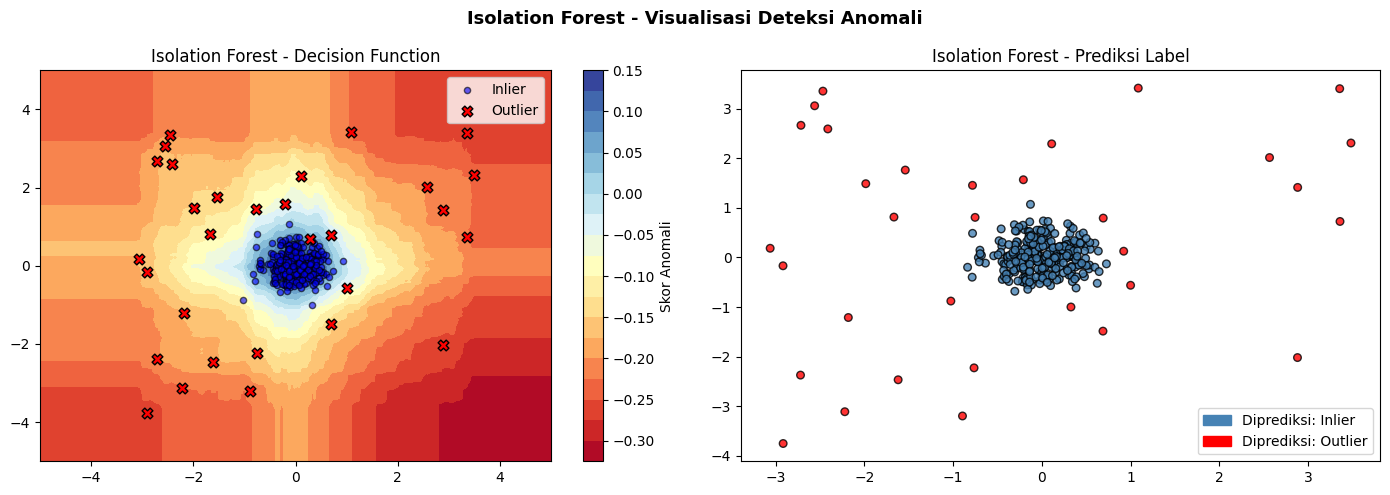

In [6]:
# Visualisasi: decision function dan prediksi
xx, yy = np.meshgrid(
    np.linspace(-5, 5, 200),
    np.linspace(-5, 5, 200)
)
Z_iso = iso_forest.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z_iso = Z_iso.reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Decision function (skor anomali)
c = ax1.contourf(xx, yy, Z_iso, levels=20, cmap='RdYlBu')
plt.colorbar(c, ax=ax1, label='Skor Anomali')
ax1.scatter(X_inliers[:, 0], X_inliers[:, 1],
            c='blue', edgecolor='k', s=20, label='Inlier', alpha=0.6)
ax1.scatter(X_outliers[:, 0], X_outliers[:, 1],
            c='red', edgecolor='k', s=60, marker='X', label='Outlier')
ax1.set_title('Isolation Forest - Decision Function')
ax1.legend()
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)

# Panel 2: Prediksi hasil
colors_pred = ['red' if p == -1 else 'steelblue' for p in y_pred_iso]
ax2.scatter(X_all[:, 0], X_all[:, 1],
            c=colors_pred, edgecolor='k', s=30, alpha=0.8)
from matplotlib.patches import Patch
legend_els = [Patch(color='steelblue', label='Diprediksi: Inlier'),
              Patch(color='red', label='Diprediksi: Outlier')]
ax2.legend(handles=legend_els)
ax2.set_title('Isolation Forest - Prediksi Label')

plt.suptitle('Isolation Forest - Visualisasi Deteksi Anomali',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. One-Class SVM untuk Novelty Detection

### Penjelasan Teori

**One-Class SVM** adalah ekstensi dari Support Vector Machine (SVM) yang didesain untuk **novelty detection**: model hanya dilatih pada data normal, lalu belajar membentuk batas keputusan di sekitar data tersebut.

**Cara kerjanya:**
1. Algoritma memetakan data ke ruang berdimensi tinggi menggunakan kernel function (biasanya RBF).
2. Di ruang baru tersebut, algoritma mencari hyperplane yang memisahkan data dari titik origin dengan margin semaksimal mungkin.
3. Data yang berada di dalam batas hyperplane dianggap normal; yang di luar dianggap novelty.

**Parameter penting:**
- `kernel`: Fungsi kernel, biasanya `'rbf'` (Radial Basis Function).
- `nu`: Upper bound proporsi outlier yang diperbolehkan dalam data pelatihan dan lower bound proporsi support vectors. Rentang: (0, 1].
- `gamma`: Parameter kernel RBF. Nilai kecil = batas lebih halus; nilai besar = batas lebih ketat mengikuti data.

**Kapan menggunakan One-Class SVM:**
- Ketika data pelatihan hanya berisi data normal (tidak ada outlier yang diketahui).
- Ketika ingin mendeteksi data baru yang berada di luar distribusi normal yang sudah diketahui.
- Cocok untuk dataset berukuran kecil hingga menengah karena kompleksitas komputasinya lebih tinggi.

**Perbedaan dari Isolation Forest:**
- One-Class SVM bersifat **novelty detector** (dilatih pada data bersih saja).
- Isolation Forest bersifat **outlier detector** (data pelatihan bisa mengandung anomali).

In [7]:
from sklearn.svm import OneClassSVM

# Untuk novelty detection: latih HANYA pada data normal
X_train_normal = X_inliers.copy()

# Buat data test: campuran normal dan novel
X_novel = rng.uniform(low=-4, high=4, size=(30, 2))
X_test_mix = np.vstack([X_inliers[:50], X_novel])
y_test_mix  = np.hstack([
    np.ones(50, dtype=int),
    -np.ones(30, dtype=int)
])

# Latih One-Class SVM pada data normal saja
oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
oc_svm.fit(X_train_normal)

# Prediksi pada data test campuran
y_pred_svm = oc_svm.predict(X_test_mix)

print("One-Class SVM - Hasil Prediksi pada Data Test:")
print(f"  Diprediksi sebagai normal (+1):  {(y_pred_svm == 1).sum()}")
print(f"  Diprediksi sebagai novelty (-1): {(y_pred_svm == -1).sum()}")
print()
print("Classification Report - One-Class SVM:")
print(classification_report(
    y_test_mix, y_pred_svm,
    target_names=['Novelty (-1)', 'Normal (+1)']
))

One-Class SVM - Hasil Prediksi pada Data Test:
  Diprediksi sebagai normal (+1):  46
  Diprediksi sebagai novelty (-1): 34

Classification Report - One-Class SVM:
              precision    recall  f1-score   support

Novelty (-1)       0.88      1.00      0.94        30
 Normal (+1)       1.00      0.92      0.96        50

    accuracy                           0.95        80
   macro avg       0.94      0.96      0.95        80
weighted avg       0.96      0.95      0.95        80



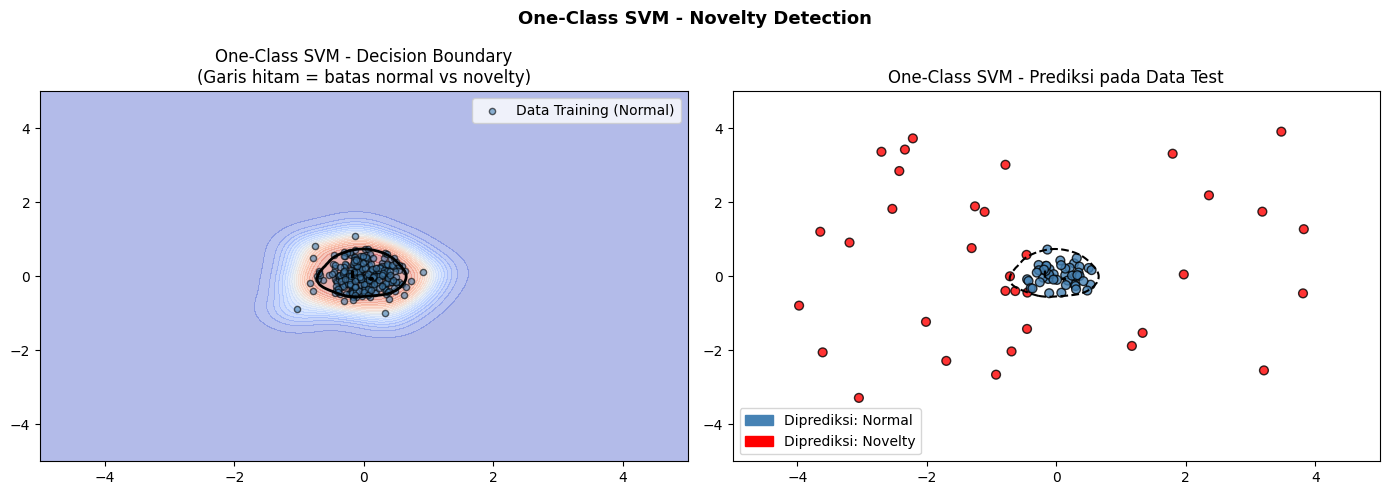

In [8]:
# Visualisasi batas keputusan One-Class SVM
Z_svm = oc_svm.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z_svm = Z_svm.reshape(xx.shape)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Batas keputusan
ax1.contourf(xx, yy, Z_svm, levels=20, cmap='coolwarm', alpha=0.4)
ax1.contour(xx, yy, Z_svm, levels=[0], colors='k', linewidths=2)
ax1.scatter(X_train_normal[:, 0], X_train_normal[:, 1],
            c='steelblue', edgecolor='k', s=20, label='Data Training (Normal)', alpha=0.6)
ax1.set_title('One-Class SVM - Decision Boundary\n(Garis hitam = batas normal vs novelty)')
ax1.legend()
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)

# Panel 2: Hasil prediksi pada test set
colors_svm = ['red' if p == -1 else 'steelblue' for p in y_pred_svm]
ax2.scatter(X_test_mix[:, 0], X_test_mix[:, 1],
            c=colors_svm, edgecolor='k', s=40, alpha=0.8)
ax2.contour(xx, yy, Z_svm, levels=[0], colors='black', linewidths=1.5, linestyles='--')
legend_els2 = [Patch(color='steelblue', label='Diprediksi: Normal'),
               Patch(color='red', label='Diprediksi: Novelty')]
ax2.legend(handles=legend_els2)
ax2.set_title('One-Class SVM - Prediksi pada Data Test')

plt.suptitle('One-Class SVM - Novelty Detection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 4. Local Outlier Factor (LOF)

### Penjelasan Teori

**Local Outlier Factor (LOF)** adalah algoritma deteksi anomali berbasis kepadatan lokal. Berbeda dari Isolation Forest yang bersifat global, LOF mengukur seberapa terisolasi sebuah titik data dibandingkan dengan **tetangga lokalnya**.

**Cara kerjanya:**
1. Untuk setiap titik data, LOF menghitung kepadatan lokal berdasarkan jarak ke k tetangga terdekatnya.
2. LOF score dihitung sebagai rasio kepadatan lokal titik tersebut dibandingkan dengan rata-rata kepadatan tetangganya.
3. **LOF score sekitar 1.0**: titik berada dalam kepadatan yang mirip dengan tetangganya (inlier).
4. **LOF score jauh di atas 1.0**: titik berada dalam area yang jauh lebih jarang dibandingkan tetangganya (outlier).

**Keunggulan LOF:**
- Sangat efektif untuk dataset dengan kepadatan yang bervariasi (tidak seragam).
- Mendeteksi **anomali lokal**: sebuah titik bisa menjadi outlier di satu area meskipun bukan outlier secara global.

**Keterbatasan LOF:**
- **Tidak mendukung prediksi pada data baru** (tidak ada metode `predict` pada data yang belum dilihat saat training). Hanya bisa digunakan untuk deteksi dalam dataset yang sama.
- Kurang efisien untuk dataset besar karena kompleksitas komputasi berbasis tetangga.
- Sensitif terhadap pemilihan parameter `n_neighbors`.

**Parameter penting:**
- `n_neighbors`: Jumlah tetangga yang dipertimbangkan untuk kepadatan lokal.
- `contamination`: Proporsi perkiraan outlier.
- `novelty=True`: Ubah LOF menjadi novelty detector (mendukung prediksi data baru), tapi harus dilatih pada data bersih.

In [9]:
from sklearn.neighbors import LocalOutlierFactor

# LOF sebagai outlier detector (novelty=False, default)
lof = LocalOutlierFactor(
    n_neighbors=20,
    contamination=0.1
)

# fit_predict: latih dan prediksi sekaligus (untuk outlier detection)
y_pred_lof = lof.fit_predict(X_all)
lof_scores  = lof.negative_outlier_factor_  # skor negatif LOF

print("Local Outlier Factor - Hasil Prediksi:")
print(f"  Diprediksi sebagai inlier  (+1): {(y_pred_lof == 1).sum()}")
print(f"  Diprediksi sebagai outlier (-1): {(y_pred_lof == -1).sum()}")
print()
print("Classification Report - LOF:")
print(classification_report(
    y_true, y_pred_lof,
    target_names=['Outlier (-1)', 'Inlier (+1)']
))

Local Outlier Factor - Hasil Prediksi:
  Diprediksi sebagai inlier  (+1): 297
  Diprediksi sebagai outlier (-1): 33

Classification Report - LOF:
              precision    recall  f1-score   support

Outlier (-1)       0.88      0.97      0.92        30
 Inlier (+1)       1.00      0.99      0.99       300

    accuracy                           0.98       330
   macro avg       0.94      0.98      0.96       330
weighted avg       0.99      0.98      0.99       330



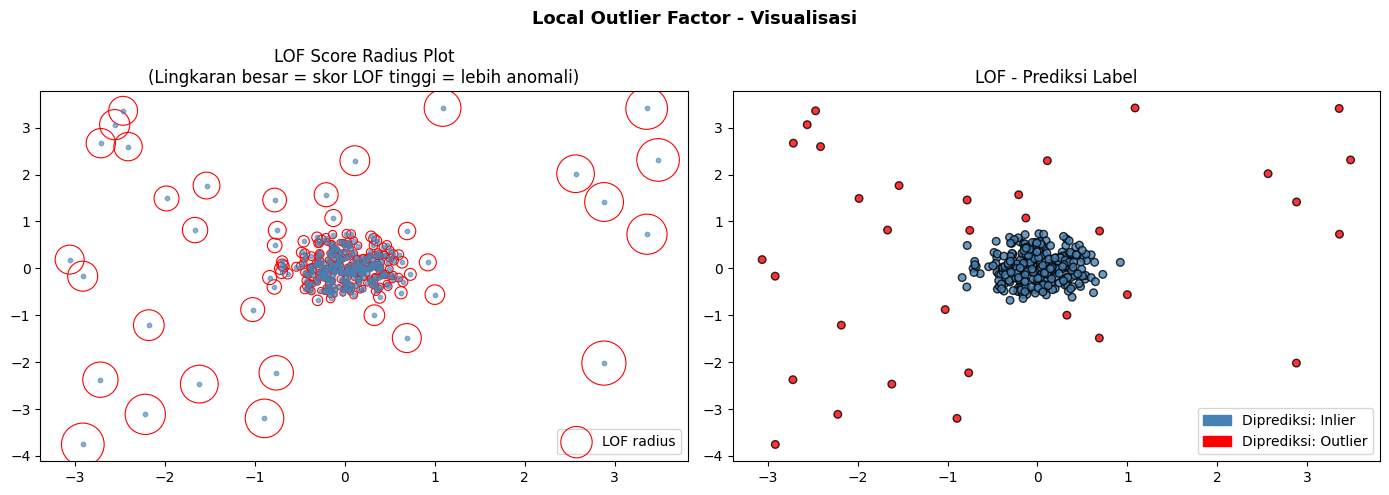

In [10]:
# Visualisasi LOF scores
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: LOF radius plot (semakin besar radius, semakin besar skor LOF)
radius = (lof_scores.max() - lof_scores) / (lof_scores.max() - lof_scores.min())
ax1.scatter(X_all[:, 0], X_all[:, 1],
            s=1000 * radius + 10, edgecolor='red',
            facecolor='none', linewidths=0.8, label='LOF radius')
ax1.scatter(X_all[:, 0], X_all[:, 1],
            c='steelblue', s=10, alpha=0.6)
ax1.set_title('LOF Score Radius Plot\n(Lingkaran besar = skor LOF tinggi = lebih anomali)')
ax1.legend()

# Panel 2: Prediksi warna
colors_lof = ['red' if p == -1 else 'steelblue' for p in y_pred_lof]
ax2.scatter(X_all[:, 0], X_all[:, 1],
            c=colors_lof, edgecolor='k', s=30, alpha=0.8)
legend_els3 = [Patch(color='steelblue', label='Diprediksi: Inlier'),
               Patch(color='red', label='Diprediksi: Outlier')]
ax2.legend(handles=legend_els3)
ax2.set_title('LOF - Prediksi Label')

plt.suptitle('Local Outlier Factor - Visualisasi', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Evaluasi Model Deteksi Outlier

### Penjelasan Teori

Mengevaluasi model deteksi anomali lebih menantang dibandingkan klasifikasi biasa karena:
1. Label anomali biasanya sangat jarang (imbalanced).
2. Dalam skenario nyata, label mungkin tidak tersedia.

**Metrik yang umum digunakan:**

- **Precision**: Dari semua yang diprediksi anomali, berapa persen yang benar-benar anomali?
- **Recall**: Dari semua yang benar-benar anomali, berapa persen yang berhasil terdeteksi?
- **F1-Score**: Harmonic mean antara Precision dan Recall.
- **ROC-AUC**: Area under the ROC curve; mengukur kemampuan diskriminasi model terhadap berbagai threshold.
- **Average Precision (AP)**: Area under the Precision-Recall curve; lebih informatif untuk data tidak seimbang.

**Perhatian penting:**
Dalam deteksi anomali, biasanya lebih penting untuk memaksimalkan **Recall** (jangan sampai ada anomali yang terlewat) meskipun harus mengorbankan Precision (lebih banyak false positive yang diterima).

In [11]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score
)

# Konversi label: scikit-learn menggunakan +1/-1, tapi metrik biasanya 0/1
# Kita anggap anomali (=-1) sebagai positif kelas 1 untuk evaluasi
y_true_bin  = (y_true == -1).astype(int)   # 1=anomali, 0=normal
y_pred_iso_bin = (y_pred_iso == -1).astype(int)
y_pred_lof_bin = (y_pred_lof == -1).astype(int)

# Skor kontinu untuk AUC
scores_iso_neg = -scores_iso  # nilai lebih tinggi = lebih anomali

results_eval = pd.DataFrame({
    'Algoritma': ['Isolation Forest', 'LOF'],
    'Precision': [
        round(precision_score(y_true_bin, y_pred_iso_bin, zero_division=0), 4),
        round(precision_score(y_true_bin, y_pred_lof_bin, zero_division=0), 4)
    ],
    'Recall': [
        round(recall_score(y_true_bin, y_pred_iso_bin, zero_division=0), 4),
        round(recall_score(y_true_bin, y_pred_lof_bin, zero_division=0), 4)
    ],
    'F1-Score': [
        round(f1_score(y_true_bin, y_pred_iso_bin, zero_division=0), 4),
        round(f1_score(y_true_bin, y_pred_lof_bin, zero_division=0), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_true_bin, scores_iso_neg), 4),
        round(roc_auc_score(y_true_bin, -lof_scores), 4)
    ]
})

print("Perbandingan Metrik Evaluasi Model Deteksi Outlier:")
display(results_eval.set_index('Algoritma'))

Perbandingan Metrik Evaluasi Model Deteksi Outlier:


,Precision,Recall,F1-Score,ROC-AUC
Algoritma,,,,
Isolation Forest,0.8788,0.9667,0.9206,0.9980
LOF,0.8788,0.9667,0.9206,0.9973


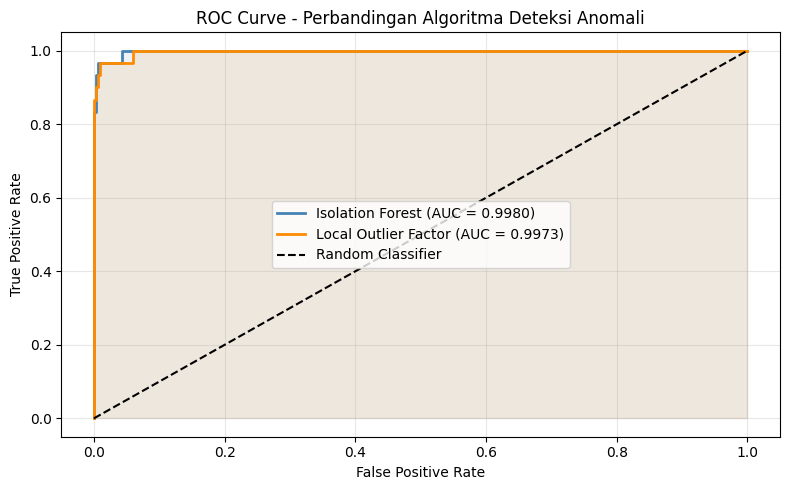

In [12]:
# ROC Curve perbandingan
from sklearn.metrics import roc_curve

fpr_iso, tpr_iso, _ = roc_curve(y_true_bin, scores_iso_neg)
fpr_lof, tpr_lof, _ = roc_curve(y_true_bin, -lof_scores)

auc_iso = roc_auc_score(y_true_bin, scores_iso_neg)
auc_lof = roc_auc_score(y_true_bin, -lof_scores)

plt.figure(figsize=(8, 5))
plt.plot(fpr_iso, tpr_iso, lw=2, color='steelblue',
         label=f'Isolation Forest (AUC = {auc_iso:.4f})')
plt.plot(fpr_lof, tpr_lof, lw=2, color='darkorange',
         label=f'Local Outlier Factor (AUC = {auc_lof:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.fill_between(fpr_iso, tpr_iso, alpha=0.1, color='steelblue')
plt.fill_between(fpr_lof, tpr_lof, alpha=0.1, color='darkorange')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Perbandingan Algoritma Deteksi Anomali')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Menangani Outlier yang Terdeteksi

### Penjelasan Teori

Setelah outlier terdeteksi, ada beberapa strategi untuk menanganinya tergantung konteks:

1. **Hapus outlier**: Untuk data preprocessing sebelum melatih model supervised. Efektif jika outlier adalah noise atau kesalahan pengukuran.

2. **Pertahankan outlier**: Jika outlier merupakan kasus yang memang menarik (misalnya deteksi penipuan).

3. **Imputasi outlier**: Gantikan nilai outlier dengan nilai statistik (median, mean) atau nilai dari model.

4. **Capping/Winsorization**: Batasi nilai ekstrem pada persentil tertentu (misalnya, nilai di atas persentil 99 dipotong menjadi nilai persentil 99).

5. **Transformasi data**: Terapkan transformasi seperti log atau Box-Cox untuk mereduksi dampak outlier.

**Perhatian:** Selalu investigasi penyebab outlier sebelum memutuskan cara penanganannya. Outlier bisa merupakan kesalahan data, atau bisa juga merupakan sinyal penting yang tidak boleh dihapus.

In [13]:
# Strategi 1: Hapus outlier dari dataset
mask_inlier = y_pred_iso == 1
X_cleaned = X_all[mask_inlier]

print(f"Dataset asli:    {X_all.shape[0]} sampel")
print(f"Setelah hapus outlier: {X_cleaned.shape[0]} sampel")
print(f"Sampel dihapus:  {X_all.shape[0] - X_cleaned.shape[0]}")
print()

# Strategi 2: Capping (Winsorization) pada fitur numerik
df_demo = pd.DataFrame(X_all, columns=['Fitur_1', 'Fitur_2'])
q01 = df_demo.quantile(0.01)
q99 = df_demo.quantile(0.99)
df_capped = df_demo.clip(lower=q01, upper=q99, axis=1)

print("Capping (Winsorization) - Perbandingan Statistik:")
compare_stats = pd.DataFrame({
    'Metrik': ['Min', 'Max', 'Std'],
    'Fitur_1 Asli':   [round(df_demo['Fitur_1'].min(), 4),
                       round(df_demo['Fitur_1'].max(), 4),
                       round(df_demo['Fitur_1'].std(), 4)],
    'Fitur_1 Capped': [round(df_capped['Fitur_1'].min(), 4),
                       round(df_capped['Fitur_1'].max(), 4),
                       round(df_capped['Fitur_1'].std(), 4)]
})
display(compare_stats)

Dataset asli:    330 sampel
Setelah hapus outlier: 297 sampel
Sampel dihapus:  33

Capping (Winsorization) - Perbandingan Statistik:


,Metrik,Fitur_1 Asli,Fitur_1 Capped
0,Min,-3.0619,-2.7184
1,Max,3.4814,2.8804
2,Std,0.7234,0.6932


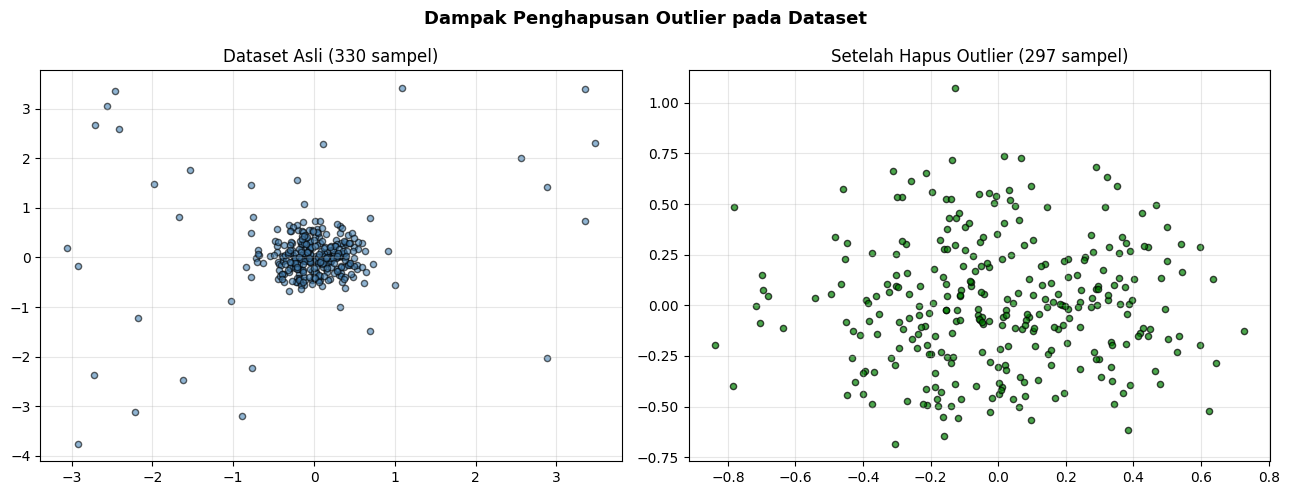

In [14]:
# Visualisasi dampak penghapusan outlier
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(X_all[:, 0], X_all[:, 1], c='steelblue', edgecolor='k', s=20, alpha=0.6)
axes[0].set_title(f'Dataset Asli ({X_all.shape[0]} sampel)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(X_cleaned[:, 0], X_cleaned[:, 1], c='green', edgecolor='k', s=20, alpha=0.7)
axes[1].set_title(f'Setelah Hapus Outlier ({X_cleaned.shape[0]} sampel)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Dampak Penghapusan Outlier pada Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Memilih Teknik Deteksi yang Tepat

### Penjelasan Teori

Pemilihan algoritma deteksi anomali sangat bergantung pada karakteristik data dan kebutuhan aplikasi. Berikut adalah panduan praktis:

| Faktor | Isolation Forest | LOF | One-Class SVM |
|--------|:--------------:|:---:|:-------------:|
| Dataset besar | Ya | Tidak | Tidak |
| Dimensi tinggi | Ya | Tidak | Kadang |
| Kepadatan tidak seragam | Tidak | Ya | Sebagian |
| Novelty detection | Ya | Ya (novelty=True) | Ya |
| Prediksi data baru | Ya | Tidak (default) | Ya |
| Dilatih pada data kotor | Ya | Ya | Tidak |
| Interpretabilitas | Sedang | Tinggi (skor lokal) | Rendah |

**Rekomendasi umum:**
- Mulai dengan **Isolation Forest** untuk dataset besar dan berdimensi tinggi karena efisiensinya.
- Gunakan **LOF** ketika data memiliki kepadatan yang sangat bervariasi antar region.
- Gunakan **One-Class SVM** ketika hanya memiliki data normal untuk pelatihan (novelty detection murni).
- Pertimbangkan **ensemble** dari beberapa metode untuk meningkatkan robustness.

In [15]:
# Tabel perbandingan algoritma (dari buku)
data_compare = {
    "Algoritma": ["Isolation Forest", "Local Outlier Factor", "One-Class SVM"],
    "Menangani Dimensi Tinggi": ["Ya", "Tidak", "Kadang"],
    "Belajar dari Data Tak Berlabel": ["Ya", "Ya", "Tidak (novelty saja)"],
    "Prediksi Data Baru": ["Ya", "Tidak", "Ya"],
    "Skala ke Data Besar": ["Ya", "Tidak", "Tidak"],
    "Robust Terhadap Variasi Kepadatan": ["Tidak", "Ya", "Sebagian"],
    "Kekuatan Utama": [
        "Cepat, skalabel, mudah digunakan",
        "Mendeteksi anomali lokal dengan kepadatan bervariasi",
        "Pemodelan batas berbasis kernel"
    ]
}
summary_df = pd.DataFrame(data_compare).set_index("Algoritma")
print("Perbandingan Algoritma Deteksi Anomali:")
display(summary_df)

Perbandingan Algoritma Deteksi Anomali:


,Menangani Dimensi Tinggi,Belajar dari Data Tak Berlabel,Prediksi Data Baru,Skala ke Data Besar,Robust Terhadap Variasi Kepadatan,Kekuatan Utama
Algoritma,,,,,,
Isolation Forest,Ya,Ya,Ya,Ya,Tidak,"Cepat, skalabel, mudah digunakan"
Local Outlier Factor,Tidak,Ya,Tidak,Tidak,Ya,Mendeteksi anomali lokal dengan kepadatan berv...
One-Class SVM,Kadang,Tidak (novelty saja),Ya,Tidak,Sebagian,Pemodelan batas berbasis kernel


In [16]:
# Demonstrasi pemilihan otomatis berdasarkan karakteristik data
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM

# Skenario 1: Data besar, dimensi tinggi => Isolation Forest
print("Skenario 1: Data besar dan dimensi tinggi")
model_s1 = IsolationForest(contamination=0.1, random_state=2024)
print(f"  Algoritma terpilih: {model_s1.__class__.__name__}")
print(f"  Alasan: Efisien, scalable, cocok untuk high-dimensional data.")
print()

# Skenario 2: Data dengan kepadatan bervariasi => LOF
print("Skenario 2: Data dengan kepadatan cluster yang bervariasi")
model_s2 = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
print(f"  Algoritma terpilih: {model_s2.__class__.__name__}")
print(f"  Alasan: Mendeteksi anomali lokal, tidak terpengaruh perbedaan kepadatan global.")
print()

# Skenario 3: Hanya data normal untuk training => One-Class SVM
print("Skenario 3: Hanya data normal tersedia untuk pelatihan (novelty detection)")
model_s3 = OneClassSVM(kernel='rbf', gamma='scale', nu=0.1)
print(f"  Algoritma terpilih: {model_s3.__class__.__name__}")
print(f"  Alasan: Mampu mempelajari batas dari data normal saja.")

Skenario 1: Data besar dan dimensi tinggi
  Algoritma terpilih: IsolationForest
  Alasan: Efisien, scalable, cocok untuk high-dimensional data.

Skenario 2: Data dengan kepadatan cluster yang bervariasi
  Algoritma terpilih: LocalOutlierFactor
  Alasan: Mendeteksi anomali lokal, tidak terpengaruh perbedaan kepadatan global.

Skenario 3: Hanya data normal tersedia untuk pelatihan (novelty detection)
  Algoritma terpilih: OneClassSVM
  Alasan: Mampu mempelajari batas dari data normal saja.


---
## 8. Latihan Komprehensif: Isolation Forest pada Dataset Nyata

### Deskripsi

Latihan ini mensimulasikan skenario deteksi anomali nyata menggunakan dataset sintetis yang menyerupai data sensor industri: klaster besar data normal dengan sekelompok kecil outlier yang tersebar.

In [17]:
# Exercise 1: Isolation Forest pada dataset sintetis seperti dunia nyata
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Generate data: inlier Gaussian + outlier uniform
rng2 = np.random.RandomState(42)
n_in, n_out = 400, 40
X_in2  = rng2.randn(n_in, 2)
X_out2 = rng2.uniform(-6, 6, (n_out, 2))
X_real = np.vstack([X_in2, X_out2])
y_real = np.hstack([np.ones(n_in), -np.ones(n_out)])

# Scale data
scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

# Terapkan Isolation Forest
iso_real = IsolationForest(contamination=0.09, random_state=2024)
iso_real.fit(X_real_scaled)
y_pred_real = iso_real.predict(X_real_scaled)

# Evaluasi
y_real_bin  = (y_real == -1).astype(int)
y_pred_bin2 = (y_pred_real == -1).astype(int)

from sklearn.metrics import classification_report
report_dict = classification_report(
    y_real_bin, y_pred_bin2,
    target_names=['Normal', 'Anomali'],
    output_dict=True
)
report_df2 = pd.DataFrame(report_dict).transpose().round(4)
print("Hasil Evaluasi Isolation Forest - Dataset Seperti Dunia Nyata:")
display(report_df2)

Hasil Evaluasi Isolation Forest - Dataset Seperti Dunia Nyata:


,precision,recall,f1-score,support
Normal,0.9875,0.9875,0.9875,400.0000
Anomali,0.8750,0.8750,0.8750,40.0000
accuracy,0.9773,0.9773,0.9773,0.9773
macro avg,0.9312,0.9312,0.9312,440.0000
weighted avg,0.9773,0.9773,0.9773,440.0000


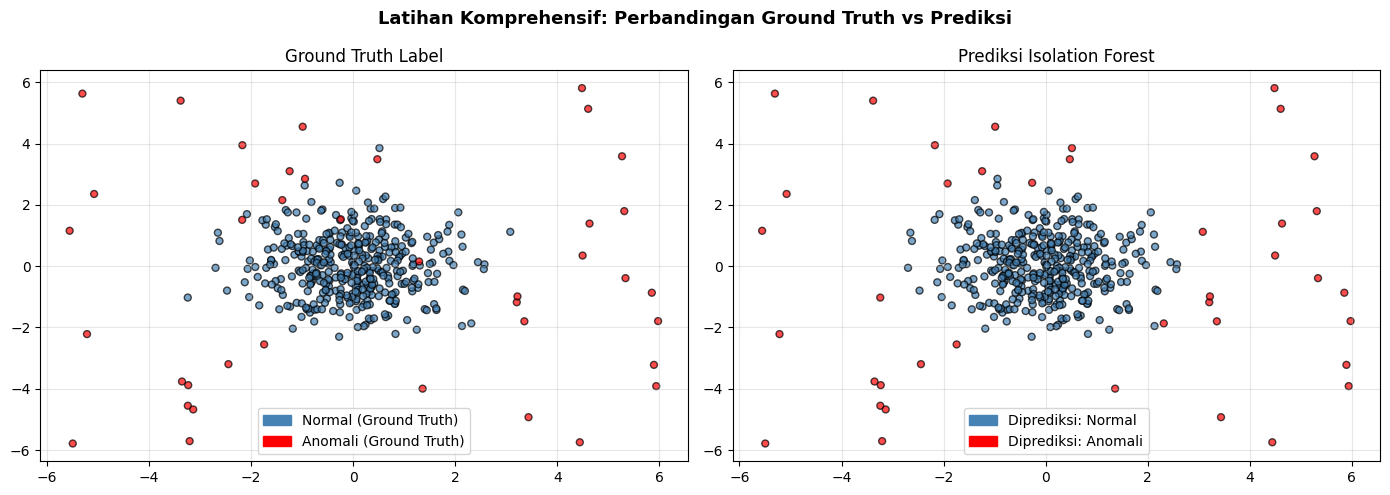

In [18]:
# Visualisasi hasil akhir
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Ground truth
colors_gt = ['steelblue' if y == 1 else 'red' for y in y_real]
axes[0].scatter(X_real[:, 0], X_real[:, 1],
                c=colors_gt, edgecolor='k', s=25, alpha=0.7)
legend_gt = [Patch(color='steelblue', label='Normal (Ground Truth)'),
             Patch(color='red', label='Anomali (Ground Truth)')]
axes[0].legend(handles=legend_gt)
axes[0].set_title('Ground Truth Label')
axes[0].grid(True, alpha=0.3)

# Panel 2: Prediksi Isolation Forest
colors_if = ['steelblue' if p == 1 else 'red' for p in y_pred_real]
axes[1].scatter(X_real[:, 0], X_real[:, 1],
                c=colors_if, edgecolor='k', s=25, alpha=0.7)
legend_if = [Patch(color='steelblue', label='Diprediksi: Normal'),
             Patch(color='red', label='Diprediksi: Anomali')]
axes[1].legend(handles=legend_if)
axes[1].set_title('Prediksi Isolation Forest')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Latihan Komprehensif: Perbandingan Ground Truth vs Prediksi',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Ringkasan Chapter 11

| Konsep | Kelas/Fungsi scikit-learn | Deskripsi |
|--------|--------------------------|-----------|
| Outlier Detection | `IsolationForest()` | Isolasi anomali dengan random tree partitioning |
| Novelty Detection | `OneClassSVM()` | Pelajari batas data normal, deteksi novelty baru |
| Kepadatan Lokal | `LocalOutlierFactor()` | Deteksi anomali berbasis kepadatan tetangga lokal |
| Skor Anomali | `decision_function()` | Nilai kontinu: semakin rendah, semakin anomali |
| Label Prediksi | `predict()` | +1 = inlier, -1 = outlier/novelty |
| Evaluasi | `roc_auc_score()`, `f1_score()` | Metrik evaluasi berbasis label ground truth |

### Poin Kunci untuk Diingat:

1. **Outlier vs Novelty**: Outlier detection berasumsi data training sudah mengandung anomali; novelty detection berasumsi data training hanya berisi data normal.

2. **Isolation Forest** bekerja berdasarkan prinsip bahwa anomali lebih mudah diisolasi (path lebih pendek di pohon). Sangat efisien untuk data besar dan berdimensi tinggi.

3. **One-Class SVM** membangun batas hyperplane di sekitar data normal menggunakan fungsi kernel. Cocok untuk novelty detection tapi lebih lambat untuk dataset besar.

4. **LOF** mengukur kepadatan lokal relatif terhadap tetangga. Sangat efektif untuk dataset dengan kepadatan tidak seragam, tapi tidak bisa memprediksi data baru secara langsung.

5. **Parameter `contamination`** harus disesuaikan dengan estimasi proporsi anomali dalam data. Nilai yang terlalu tinggi akan mendeteksi terlalu banyak false positive.

6. **Setelah deteksi**, selalu investigasi penyebab outlier sebelum memutuskan untuk menghapus, mengimputasi, atau mempertahankannya.

7. **Mulai dengan Isolation Forest** sebagai baseline karena efisiensinya, lalu iterasi ke metode lain berdasarkan kebutuhan spesifik data.